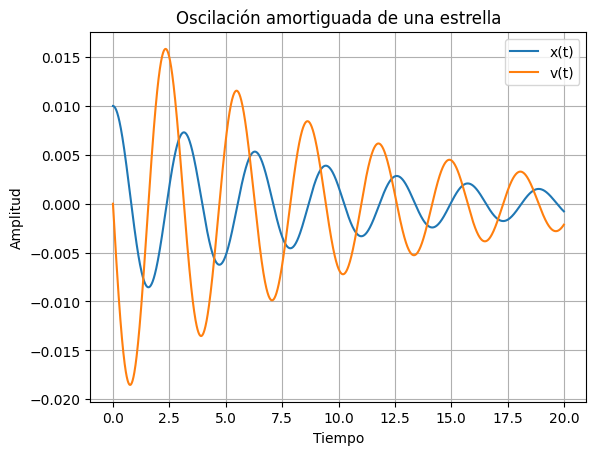

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros
omega0 = 2.0       # frecuencia natural
xi = 0.1           # amortiguamiento
R0 = 1.0           # radio medio (puedes cambiarlo)

# Condiciones iniciales
x1_0 = 0.01 * R0   # posición
x2_0 = 0.0         # velocidad

# Tiempo
h = 0.01
t_max = 20
t = np.arange(0, t_max, h)

# Sistema de ecuaciones
def f(x1, x2):
    dx1dt = x2
    dx2dt = -omega0 * xi * x2 - omega0**2 * x1
    return dx1dt, dx2dt

# RK4
x1 = np.zeros(len(t))
x2 = np.zeros(len(t))

x1[0] = x1_0
x2[0] = x2_0

for i in range(len(t)-1):
    k1_1, k1_2 = f(x1[i], x2[i])
    
    k2_1, k2_2 = f(x1[i] + 0.5*h*k1_1, x2[i] + 0.5*h*k1_2)
    
    k3_1, k3_2 = f(x1[i] + 0.5*h*k2_1, x2[i] + 0.5*h*k2_2)
    
    k4_1, k4_2 = f(x1[i] + h*k3_1, x2[i] + h*k3_2)
    
    x1[i+1] = x1[i] + (h/6)*(k1_1 + 2*k2_1 + 2*k3_1 + k4_1)
    x2[i+1] = x2[i] + (h/6)*(k1_2 + 2*k2_2 + 2*k3_2 + k4_2)

# Graficar
plt.figure()
plt.plot(t, x1, label='x(t)')
plt.plot(t, x2, label='v(t)')
plt.xlabel('Tiempo')
plt.ylabel('Amplitud')
plt.title('Oscilación amortiguada de una estrella')
plt.legend()
plt.grid()

plt.show()